# KSPHM-KIMM 2026 — 베어링 RUL 예측: 데이터 분석 walkthrough

이 노트북은 **무엇을, 왜, 어떻게 했는지** 처음부터 끝까지 따라갈 수 있게 정리한 분석 보고서입니다. `src/` 모듈만 import하면 모든 단계를 재현할 수 있습니다.

---

## 한눈에 보기

**과제**: 베어링 가속 열화 시험 데이터로 검증 시점부터 고장까지 남은 시간(RUL)을 **초 단위**로 예측. 평가식이 비대칭이라 **과대 예측에 큰 페널티**.

**입력 데이터** (Train 4세트, 466개 진동 파일 + 4개 운영 CSV)
- 진동(TDMS): 4채널 @ 25.6 kHz, 10분 주기로 1분씩 측정
- 운영(CSV): Torque / Motor RPM / Temp(전·후면) @ 0.1 Hz

**파이프라인**
```
TDMS  ─load_tdms_file──▶  DataFrame ─tdms_to_array─▶  (4, N) np.ndarray
                                                            │
                                                            ▼
                                            channel_features (utils.feature)
                                                fast_kurtogram으로 밴드 자동 선정
                                                            │
                                                            ▼
                                                4 × 18 = 72 피처/파일 + Operation 9 + meta 6
                                                            │
                                                            ▼
                                                outputs/features_utils/train{1..4}.parquet
```

**핵심 결과 (4 Train)**

| Train | 시간 | 종료 토크 | 고장 부위 | 추정 결함 | 최강 단조 신호 (Spearman ρ) |
|---|---|---|---|---|---|
| 1 | 20.9 h | -25.6 Nm | Front | **내륜(BPFI)** | CH2 env_BPFI_1x **0.87** |
| 2 | 18.9 h | -21.0 Nm | Rear  | **복합(BPFI+BPFO)** | CH3 RMS **0.84** |
| 3 | 14.8 h | -20.8 Nm | Front | **외륜(BPFO) + 임팩트** | CH1 env_BPFO_2x **0.86** |
| 4 | 22.9 h | -27.4 Nm | Rear  | **사전 결함 + 점진** | CH4 env_BPFI_1x **0.86** |

→ 4 Train 모두 토크 -20 Nm 자동 정지에 의해 시험 종료(200°C 트리거는 한 번도 도달하지 못함).
→ 모든 Train에서 ρ ≥ 0.84 단조 신호 확보 → 모델링 단계 회귀 입력으로 사용 가능.

**산출물**
```
src/{io_tdms, operation, features_utils, export_view}.py   - 파이프라인 코드
utils/{utils, kurtogram}.py                                - 외부 신호처리 함수
outputs/features_utils/train{1..4}.parquet                 - 피처 캐시 (4×87)
outputs/features_utils/selected_bands.csv                  - kurtogram 밴드
outputs/figures/01~06_*.png                                - EDA 6종
outputs/csv/Train{i}_Vibration/000XXX.csv                  - 다운샘플(800Hz) 열람용 CSV (gitignore)
outputs/plots/Train{i}_{Operation,Vibration}/...png        - 파일별 시각화
```

---

## 목차
0. **환경 준비** — 경로 설정과 라이브러리 로드
1. **챌린지 개요** — RUL과 비대칭 평가식
2. **데이터 인벤토리** — 파일 구조와 양
3. **Operation CSV** — 컬럼 정리와 4 Train 종료 조건 비교
4. **TDMS 진동 데이터 읽기** — 표준 nptdms API + NumPy 변환
5. **Operation–Vibration 동기화** — 1분 윈도 정렬
6. **피처 엔지니어링** — `utils.feature` 18종 + `fast_kurtogram` 자동 밴드
7. **466 파일 일괄 처리** — Parquet 캐시
8. **EDA 시각화 6종** — 트렌드 / Operation / 파형·FFT / 엔벨로프 / HI / Spearman
9. **종합 발견** — 4 Train 결론 표
10. **다음 단계** — 모델링 우선순위

---

## 0. 환경 준비

프로젝트 루트와 `utils/` 경로를 `sys.path`에 추가하고, 분석에 필요한 라이브러리를 임포트합니다.

**필요 패키지**: `nptdms`, `numpy`, `pandas`, `scipy`, `matplotlib`, `scikit-learn`, `pyarrow`

```bash
pip install -r requirements.txt
# 또는
conda install conda-forge::nptdms numpy pandas scipy matplotlib scikit-learn pyarrow
```

In [1]:
import sys
from pathlib import Path

ROOT = Path('c:/Users/User/WorkSpace/data_challenge')
for p in (ROOT, ROOT / 'utils'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

FIG_DIR = ROOT / 'outputs' / 'figures'
FEAT_DIR = ROOT / 'outputs' / 'features_utils'

print('working dir   :', ROOT)
print('python        :', sys.version.split()[0])
print('numpy/pandas  :', np.__version__, '/', pd.__version__)

working dir   : c:\Users\User\WorkSpace\data_challenge
python        : 3.13.9
numpy/pandas  : 2.3.5 / 2.3.3


---

## 1. 챌린지 개요

### 1.1 무엇을 푸는가
한국기계연구원(KIMM)·한국PHM학회(KSPHM)가 공동 주최하는 **베어링 잔여수명(Remaining Useful Life, RUL) 예측** 대회입니다.
- **학습 데이터(Train)**: 가속 열화 시험을 정지 트리거(토크 ≤ -20 Nm 또는 하우징 200°C)까지 끝까지 돌린 "run-to-failure" 데이터 4세트
- **검증 데이터(Validation)**: 결함이 진전 중인 부분 데이터 — 그 마지막 시점에서 "앞으로 몇 초 후에 고장이 날지" 예측해야 함

### 1.2 평가식 — 왜 비대칭인가
예측 오차율 `Er = 100 × (실제 - 예측) / 실제`에 대해

| 부호 | 의미 | 점수식 | 페널티 강도 |
|---|---|---|---|
| `Er ≤ 0` | **과대** 예측 (예측 > 실제) | `0.5^(Er/20)` | **가파름** |
| `Er > 0` | **과소** 예측 (예측 < 실제) | `0.5^(Er/-50)` | 완만 |

**직관**: "아직 멀쩡하다"고 잘못 예측하다 갑자기 고장 나는 게 안전·비용 측면에서 더 위험하므로 과대 페널티가 강합니다. → 모델은 **약간 짧게(보수적으로)** 예측해야 점수에 유리합니다.

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

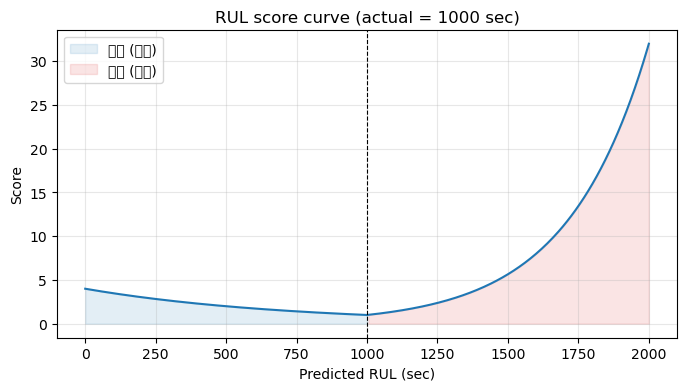

  -20% 과소 (pred=800):  score = 1.320
  +20% 과대 (pred=1200): score = 2.000  ← 페널티 큼


In [2]:
# 평가식의 비대칭성을 직접 그려서 확인합니다.
def rul_score(actual, predicted):
    er = 100.0 * (actual - predicted) / actual
    return np.where(er <= 0, 0.5 ** (er / 20.0), 0.5 ** (er / -50.0))

actual = 1000.0
preds = np.linspace(0, 2000, 401)
scores = rul_score(actual, preds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(preds, scores, lw=1.5)
ax.fill_between(preds, 0, scores, where=(preds <= actual), color='tab:blue',  alpha=0.12, label='과소 (안전)')
ax.fill_between(preds, 0, scores, where=(preds >  actual), color='tab:red',   alpha=0.12, label='과대 (위험)')
ax.axvline(actual, color='black', ls='--', lw=0.8)
ax.set_xlabel('Predicted RUL (sec)')
ax.set_ylabel('Score')
ax.set_title(f'RUL score curve (actual = {int(actual)} sec)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f'  -20% 과소 (pred=800):  score = {rul_score(1000, 800):.3f}')
print(f'  +20% 과대 (pred=1200): score = {rul_score(1000, 1200):.3f}  ← 페널티 큼')

### 1.3 제공 데이터 사양

| 항목 | 값 |
|---|---|
| 베어링 모델 | NSK 30306 (테이퍼 롤러) |
| 부하 | 축방향 15 kN, 반경방향 10 kN |
| 회전 속도 | 700 RPM ↔ 950 RPM 1시간 교번 (실측 ~740 / ~985) |
| 진동 샘플링 | **25.6 kHz × 4채널** (CH1=Front Vert, CH2=Front Axial, CH3=Rear Vert, CH4=Rear Axial) |
| 운영 샘플링 | 0.1 Hz (Torque, RPM, TC SP Front, TC SP Rear) |
| 측정 패턴 | 10분 주기로 1분만 진동 측정 → 9분 휴지 |
| 정지 트리거 | 베어링 하우징 200°C **또는** 토크 ≤ -20 Nm |

**베어링 결함 주파수 (1000 RPM 기준)**

| 결함 위치 | 약어 | 주파수 (Hz) | 의미 |
|---|---|---|---|
| 내륜 | BPFI | 140 | Ball Passing Frequency, Inner race |
| 외륜 | BPFO | 93  | Ball Passing Frequency, Outer race |
| 굴림체 | BSF | 78 | Ball Spin Frequency |
| 보호기 | FTF | 6.7 | Fundamental Train Frequency (cage) |

이 주파수들은 회전 속도에 비례 → 실제 분석에서는 `f * (rpm/1000)`로 동적 스케일링.

---

## 2. 데이터 인벤토리

어떤 파일이 몇 개 있는지부터 확인합니다.

```
Train/
├── Train1_Operation.csv          (CSV, 운영 데이터)
├── Train1_Vibration/
│   ├── 000001.tdms               (TDMS, 1분 × 4채널)
│   ├── 000002.tdms
│   ├── ...
│   └── 000126.tdms
├── Train2_Operation.csv
├── Train2_Vibration/000001.tdms ~ 000114.tdms
├── Train3_Operation.csv
├── Train3_Vibration/000001.tdms ~ 000089.tdms
├── Train4_Operation.csv
└── Train4_Vibration/000001.tdms ~ 000137.tdms  (마지막 1개 누락 — FAQ 명시)
```

In [3]:
# 각 Train의 진동 파일 개수와 Operation 행수를 한눈에 정리
rows = []
for tr in [1, 2, 3, 4]:
    op_path = ROOT / 'Train' / f'Train{tr}_Operation.csv'
    tdms_paths = sorted((ROOT / 'Train' / f'Train{tr}_Vibration').glob('*.tdms'))
    op_rows = sum(1 for _ in open(op_path, 'rb')) - 1
    rows.append({
        'Train': tr,
        'Operation rows (10s 간격)': op_rows,
        '진동 파일 수 (1min/file)': len(tdms_paths),
        '시험 시간 [hr]': round(op_rows * 10 / 3600, 1),
        'TDMS 1개 크기 [MB]': round(tdms_paths[0].stat().st_size / 1024 / 1024, 2),
    })
pd.DataFrame(rows)

,Train,Operation rows (10s 간격),진동 파일 수 (1min/file),시험 시간 [hr],TDMS 1개 크기 [MB]
0,1,7523,126,20.9,23.44
1,2,6796,114,18.9,23.44
2,3,5321,89,14.8,23.44
3,4,8259,137,22.9,23.44


> **핵심 관찰**
> - 모든 TDMS는 정확히 **23.44 MB**: `4ch × 25,600 Hz × 60 sec × 4 byte (float32) = 24,576,000 byte` + 헤더 253 byte
> - 진동은 1분만 측정 후 9분 휴지 → **총 진동 데이터는 시험 시간의 1/10**
> - Train4만 137개 파일 (**마지막 1개 결측** — FAQ 명시)

---

## 3. Operation CSV 구조 분석

### 3.1 부딪힌 문제: 인코딩
헤더의 °(degree) 문자가 한국어 CP949 영역과 충돌해 UTF-8로 못 읽습니다. `latin1`로 우회 → 컬럼명 trim/rename → `src/operation.py::load_operation()`에 캡슐화.

In [4]:
from src.operation import load_operation

df1 = load_operation(1)
print('shape  :', df1.shape, '   columns:', list(df1.columns))
print('Δt     :', df1['Time[sec]'].iloc[1] - df1['Time[sec]'].iloc[0], '초 (= 0.1 Hz)')
print('처음 3행:')
df1.head(3)

shape  : (7523, 5)    columns: ['Time[sec]', 'Torque[Nm]', 'Motor speed[rpm]', 'TC SP Front', 'TC SP Rear']
Δt     : 10 초 (= 0.1 Hz)
처음 3행:


,Time[sec],Torque[Nm],Motor speed[rpm],TC SP Front,TC SP Rear
0,11,-4.531,498.0,10.279,10.389
1,21,-4.457,736.0,10.287,10.396
2,31,-4.508,736.0,10.315,10.414


### 3.2 4 Train 종료 조건 비교

고장 부위(Front/Rear) 추정의 첫 단서는 **온도**입니다 (어느 쪽 베어링이 더 뜨거워졌나).

In [5]:
# 4 Train 정지 조건과 고장 부위 추정
rows = []
for tr in [1, 2, 3, 4]:
    df = load_operation(tr)
    tcf, tcr = df['TC SP Front'].max(), df['TC SP Rear'].max()
    end_tq   = df['Torque[Nm]'].iloc[-1]
    by_torque = end_tq <= -20
    by_temp   = max(tcf, tcr) >= 200
    trigger = ('torque' if by_torque and not by_temp else
               'temp'   if by_temp   and not by_torque else 'both')
    rows.append({
        'Train': tr,
        '시간 [hr]': round(df['Time[sec]'].iloc[-1] / 3600, 1),
        '종료 토크 [Nm]': round(end_tq, 2),
        'Front max °C': round(tcf, 1),
        'Rear max °C':  round(tcr, 1),
        '정지 트리거': trigger,
        '추정 고장 부위': 'Front' if tcf > tcr else 'Rear',
    })
pd.DataFrame(rows)

,Train,시간 [hr],종료 토크 [Nm],Front max °C,Rear max °C,정지 트리거,추정 고장 부위
0,1,20.9,-25.60,177.2,110.3,torque,Front
1,2,18.9,-21.01,108.9,180.6,torque,Rear
2,3,14.8,-20.82,191.9,124.3,torque,Front
3,4,22.9,-27.38,125.0,181.7,torque,Rear


> **핵심 관찰**
> - 4 Train 모두 **토크 -20 Nm 트리거**에서 정지 (200°C는 한 번도 도달 X)
> - 평소 토크는 -2~-5 Nm 부근, 고장 직전 음의 spike로 한 방에 -20을 뚫음 → 자동 중단
> - 인과관계: "토크가 -20 아래로 → 고장"이 아니라 "베어링 파손 → 마찰 급증 → 토크 spike → 안전 정지"
> - 온도 max로 고장 부위 추정: **Train1·3 = Front**, **Train2·4 = Rear**

---

## 4. TDMS 진동 데이터 읽기

TDMS는 NI(National Instruments) 자체 포맷이라 표준 라이브러리(`nptdms`)가 필요합니다.

### 4.1 권장 패턴 (챌린지 가이드)
```python
from nptdms import TdmsFile
import pandas as pd

def load_tdms_file(file_path):
    tdms_file = TdmsFile.read(file_path)
    df = tdms_file.as_dataframe()
    return df
```
이 함수는 한 파일을 **(1,536,000 행 × 4 열) DataFrame**으로 반환합니다.

**설치**: `conda install conda-forge::nptdms` 또는 `pip install nptdms`

In [6]:
from src.io_tdms import load_tdms_file, tdms_to_array, FS, SAMPLES_PER_CH

path = ROOT / 'Train' / 'Train1_Vibration' / '000001.tdms'
df_tdms = load_tdms_file(path)
print(f'shape   : {df_tdms.shape}   ({SAMPLES_PER_CH} samples × 4 channels)')
print(f'duration: {SAMPLES_PER_CH/FS:.1f} s @ {FS} Hz')
print(f'columns : {list(df_tdms.columns)}')
df_tdms.head(3)

shape   : (1536000, 4)   (1536000 samples × 4 channels)
duration: 60.0 s @ 25600 Hz
columns : ["/'Vibration'/'CH1'", "/'Vibration'/'CH2'", "/'Vibration'/'CH3'", "/'Vibration'/'CH4'"]


,/'Vibration'/'CH1',/'Vibration'/'CH2',/'Vibration'/'CH3',/'Vibration'/'CH4'
0,0.199032,0.559330,0.146961,0.311756
1,0.172424,0.476265,0.136757,0.276947
2,-0.170422,0.096893,-0.139332,-0.150490


### 4.2 신호처리용 NumPy 매트릭스 변환
DataFrame은 탐색·플로팅에 편리하지만 FFT/필터/Hilbert envelope은 보통 NumPy `(채널, 샘플)` 배열을 입력으로 받습니다. `tdms_to_array(df)`가 표준 변환을 합니다.

In [7]:
arr = tdms_to_array(df_tdms)
print(f'matrix shape : {arr.shape}   dtype: {arr.dtype}')
print(f'per-channel RMS: {np.sqrt((arr**2).mean(axis=1)).round(4)}')

matrix shape : (4, 1536000)   dtype: float32
per-channel RMS: [0.1505 0.196  0.1252 0.1707]


---

## 5. Operation–Vibration 동기화

**문제**: 진동 파일 i (1-based)는 t = `(i-1) × 600` 초부터 60초간 측정. 이 1분 윈도 안에 Operation 행이 6~7개 들어 있음. 모델 학습에는 **파일당 1행 요약**이 필요.

**해결**: `align_to_vibration(df_op, n_files)` — 진동 파일별 RPM/Torque/Temp 평균·표준편차·최솟값/최댓값을 한 행으로 집계.

In [8]:
from src.operation import align_to_vibration, list_vibration_files

tr = 1
files = list_vibration_files(tr)
agg = align_to_vibration(load_operation(tr), len(files))
print(f'Train{tr}: Operation {7523:,}행  →  진동 파일별 {len(agg)}행으로 집계\n')
agg.head(3)

Train1: Operation 7,523행  →  진동 파일별 126행으로 집계



,file_idx,t_start_sec,rpm_mean,rpm_std,torque_mean,torque_min,torque_std,tcf_mean,tcr_mean,tcf_max,tcr_max
0,1,0,697.666667,89.304100,-4.443667,-4.607,0.128247,10.367500,10.470833,10.518,10.621
1,2,600,740.000000,0.534522,-3.244286,-3.662,0.246714,14.325714,14.333000,14.478,14.471
2,3,1200,740.428571,0.494872,-3.032714,-3.342,0.216264,17.078286,16.761714,17.197,16.880


---

## 6. 피처 엔지니어링

### 6.1 채널별 18 피처 (`utils.feature`)
한 채널 1분 신호에 대해 다음을 추출합니다:

| 그룹 | 개수 | 피처 |
|---|---|---|
| (A) 시간영역 (원신호) | 4 | `rms`, `skew`, `kurt`, `cf` (Crest Factor = peak/rms) |
| (B) 시간영역 (필터 신호) | 4 | `rms_filter`, `skew_filter`, `kurt_filter`, `cf_filter` |
| (C) 필터 대역 RMS | 1 | `band_filter_rms` (FFT-based) |
| (D) 엔벨로프 대역 에너지 | 9 | `env_{BPFI/BPFO/BSF}_{1x/2x/3x}` (각 ±10%) |

**총 4채널 × 18 = 72 피처/파일** + Operation 9 + meta 6 = **87 컬럼**

### 6.2 베어링 결함 주파수가 왜 중요한가
회전 베어링이 결함을 가지면 **결함 위치를 굴림체가 지나갈 때마다 충격**이 발생 → 충격 주기 = 결함 주파수.
결함은 **고주파 대역(보통 1-10 kHz)에 임팩트 burst**를 만들어 그 burst가 결함 주파수로 amplitude-modulate 됩니다. → **Hilbert envelope spectrum**이 결함 진단의 표준.

### 6.3 Bandpass 대역은 어떻게 정하는가? — `fast_kurtogram`
"임팩트가 가장 강하게 변조되는 대역"이 채널마다 다릅니다 (베어링 공진 주파수). `utils/kurtogram.py::fast_kurtogram`(Antoni 2007)을 **(Train, Channel)별 말기 파일에 한 번만** 실행해 최적 [lo, hi]를 찾고, 같은 Train·Channel의 모든 파일에 그 밴드를 재사용합니다.
→ 16번만 호출 (4 Train × 4 ch). 파일당 kurtogram 호출 X.

In [9]:
from src.features_utils import per_train_bands

# Train1 4채널 envelope 밴드 (kurtogram 결과)
bands = per_train_bands(1)
print(f'{"Channel":>8} {"lo (Hz)":>10} {"hi (Hz)":>10} {"BW":>8} {"kmax":>8}  비고')
for ch, (lo, hi, info) in bands.items():
    note = '(fallback)' if info['fallback'] else ''
    print(f'{ch:>8} {lo:>10.0f} {hi:>10.0f} {info["bw"]:>8.0f} {info["kmax"]:>8.2f}  {note}')

 Channel    lo (Hz)    hi (Hz)       BW     kmax  비고
     CH1      12033      12567      533     5.61  
     CH2      12033      12567      533     9.93  
     CH3       8833      10433     1600     1.74  
     CH4       6167       6700      533     1.73  


In [10]:
# 한 채널 (Train1 마지막 파일 CH2)에서 18 피처를 직접 추출해 봅니다.
from src.features_utils import channel_features

files = list_vibration_files(1)
late = tdms_to_array(load_tdms_file(files[-1]))
rpm_late = agg.rpm_mean.iloc[-1]
lo, hi, _ = bands['CH2']

feats_one = channel_features(late[1], rpm_late, lo, hi)
pd.Series(feats_one, name=f'Train1 file{files[-1].stem} CH2 (rpm~{rpm_late:.0f})').to_frame()

,Train1 file000126 CH2 (rpm~742)
rms,2.065830
skew,-0.045003
kurt,3.161432
cf,5.410632
band_filter_rms,0.000485
rms_filter,0.062331
skew_filter,0.000001
kurt_filter,7.973528
cf_filter,13.453380
env_BPFI_1x,0.000522


### 6.4 Early vs Late 엔벨로프 비교 (Train1 CH2)

고장이 진전되면 **결함 주파수(BPFI 등)의 엔벨로프 라인이 자라야** 합니다. Train1 CH2에서 직접 확인:

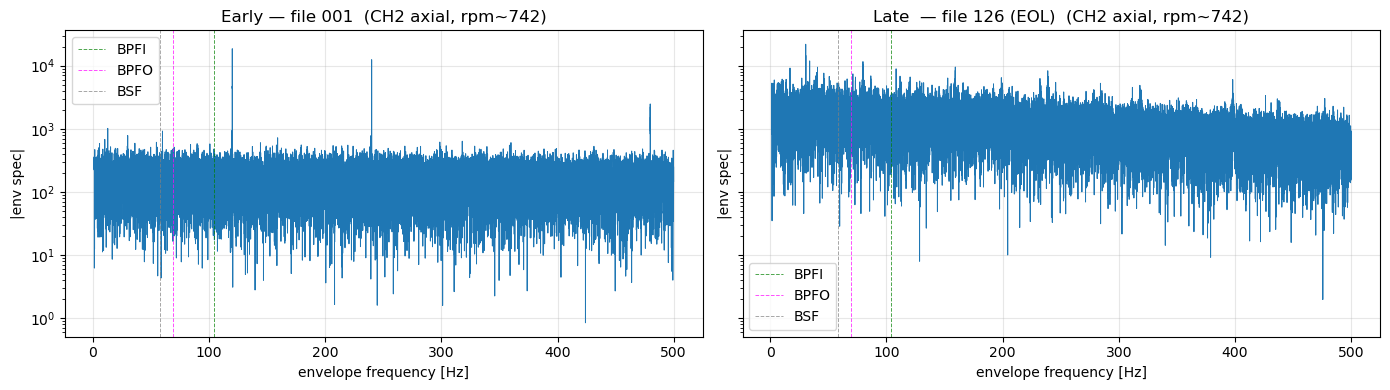

In [11]:
from scipy.signal import butter, sosfiltfilt, hilbert
from src.features_utils import BPFx_AT_1000

early = tdms_to_array(load_tdms_file(files[0]))
late_arr = tdms_to_array(load_tdms_file(files[-1]))
scale = rpm_late / 1000.0
sos = butter(4, [1000.0, 10000.0], btype='band', fs=FS, output='sos')

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, sig, title in [(axes[0], early[1],    'Early — file 001'),
                       (axes[1], late_arr[1], 'Late  — file 126 (EOL)')]:
    env = np.abs(hilbert(sosfiltfilt(sos, sig)))
    env -= env.mean()
    spec = np.abs(np.fft.rfft(env * np.hanning(len(env))))
    freqs = np.fft.rfftfreq(len(env), d=1.0/FS)
    m = (freqs >= 1) & (freqs <= 500)
    ax.plot(freqs[m], spec[m], lw=0.7)
    for name, color in [('BPFI','green'), ('BPFO','magenta'), ('BSF','gray')]:
        ax.axvline(BPFx_AT_1000[name] * scale, color=color, ls='--', lw=0.7, alpha=0.7, label=name)
    ax.set_yscale('log')
    ax.set_title(f'{title}  (CH2 axial, rpm~{rpm_late:.0f})')
    ax.set_xlabel('envelope frequency [Hz]')
    ax.set_ylabel('|env spec|')
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

> **해석**: late에서 BPFI(녹색 점선) 부근 라인이 early 대비 **약 한 자릿수 자람** → Train1 베어링은 **내륜(inner race) 결함**으로 진단.

---

## 7. 466 파일 일괄 처리 → Parquet 캐시

한 파일 처리: ~1.8 s  →  466 파일 × 1.8 s = **약 14 분**. 모델링 단계마다 재계산하면 시간이 너무 들기 때문에 한 번 추출한 결과를 **Parquet 캐시**합니다.

**실행 방법**: `python -m src.features_utils`

**산출물**:
- `outputs/features_utils/train{1..4}.parquet` — 파일당 1행, 87 컬럼
- `outputs/features_utils/selected_bands.csv` — 재현용 envelope 밴드 정보

**메타 컬럼**: `train_id`, `file_idx`, `t_start_sec`, `time_to_eol_sec` (← **RUL 라벨**), `life_frac` (0=시작, 1=EOL)

In [12]:
feats = {tr: pd.read_parquet(FEAT_DIR / f'train{tr}.parquet') for tr in [1, 2, 3, 4]}
for tr, df in feats.items():
    eol_h = (df.t_start_sec.max() + 60) / 3600
    print(f'  Train{tr}: shape={df.shape}, EOL={eol_h:.1f}h, files={len(df)}')

print('\nTrain1 첫 3행 (메타 + 핵심 피처):')
cols_show = ['file_idx','t_start_sec','time_to_eol_sec','life_frac',
             'CH2_rms','CH2_kurt','CH2_env_BPFI_1x',
             'rpm_mean','torque_min','tcf_mean']
feats[1][cols_show].head(3)

  Train1: shape=(126, 87), EOL=20.9h, files=126
  Train2: shape=(114, 87), EOL=18.9h, files=114
  Train3: shape=(89, 87), EOL=14.7h, files=89
  Train4: shape=(137, 87), EOL=22.7h, files=137

Train1 첫 3행 (메타 + 핵심 피처):


,file_idx,t_start_sec,time_to_eol_sec,life_frac,CH2_rms,CH2_kurt,CH2_env_BPFI_1x,rpm_mean,torque_min,tcf_mean
0,1,0,75060,0.000000,0.196044,3.333056,0.000044,697.666667,-4.607,10.367500
1,2,600,74460,0.007994,0.198770,3.329537,0.000042,740.000000,-3.662,14.325714
2,3,1200,73860,0.015987,0.201856,3.302368,0.000042,740.428571,-3.342,17.078286


---

## 8. EDA 시각화 6종

Parquet 캐시를 입력으로 6개 핵심 그래프를 그렸습니다 (모두 `outputs/figures/01~06_*.png`에 저장됨). 각 그림의 **목적**과 **읽어내야 할 것**을 정리합니다.

### 8.1 RMS / Peak / Kurtosis 시계열
**목적**: 시간에 따라 채널별 진동이 어떻게 변하나? 어느 채널이 "고장 채널"인가?

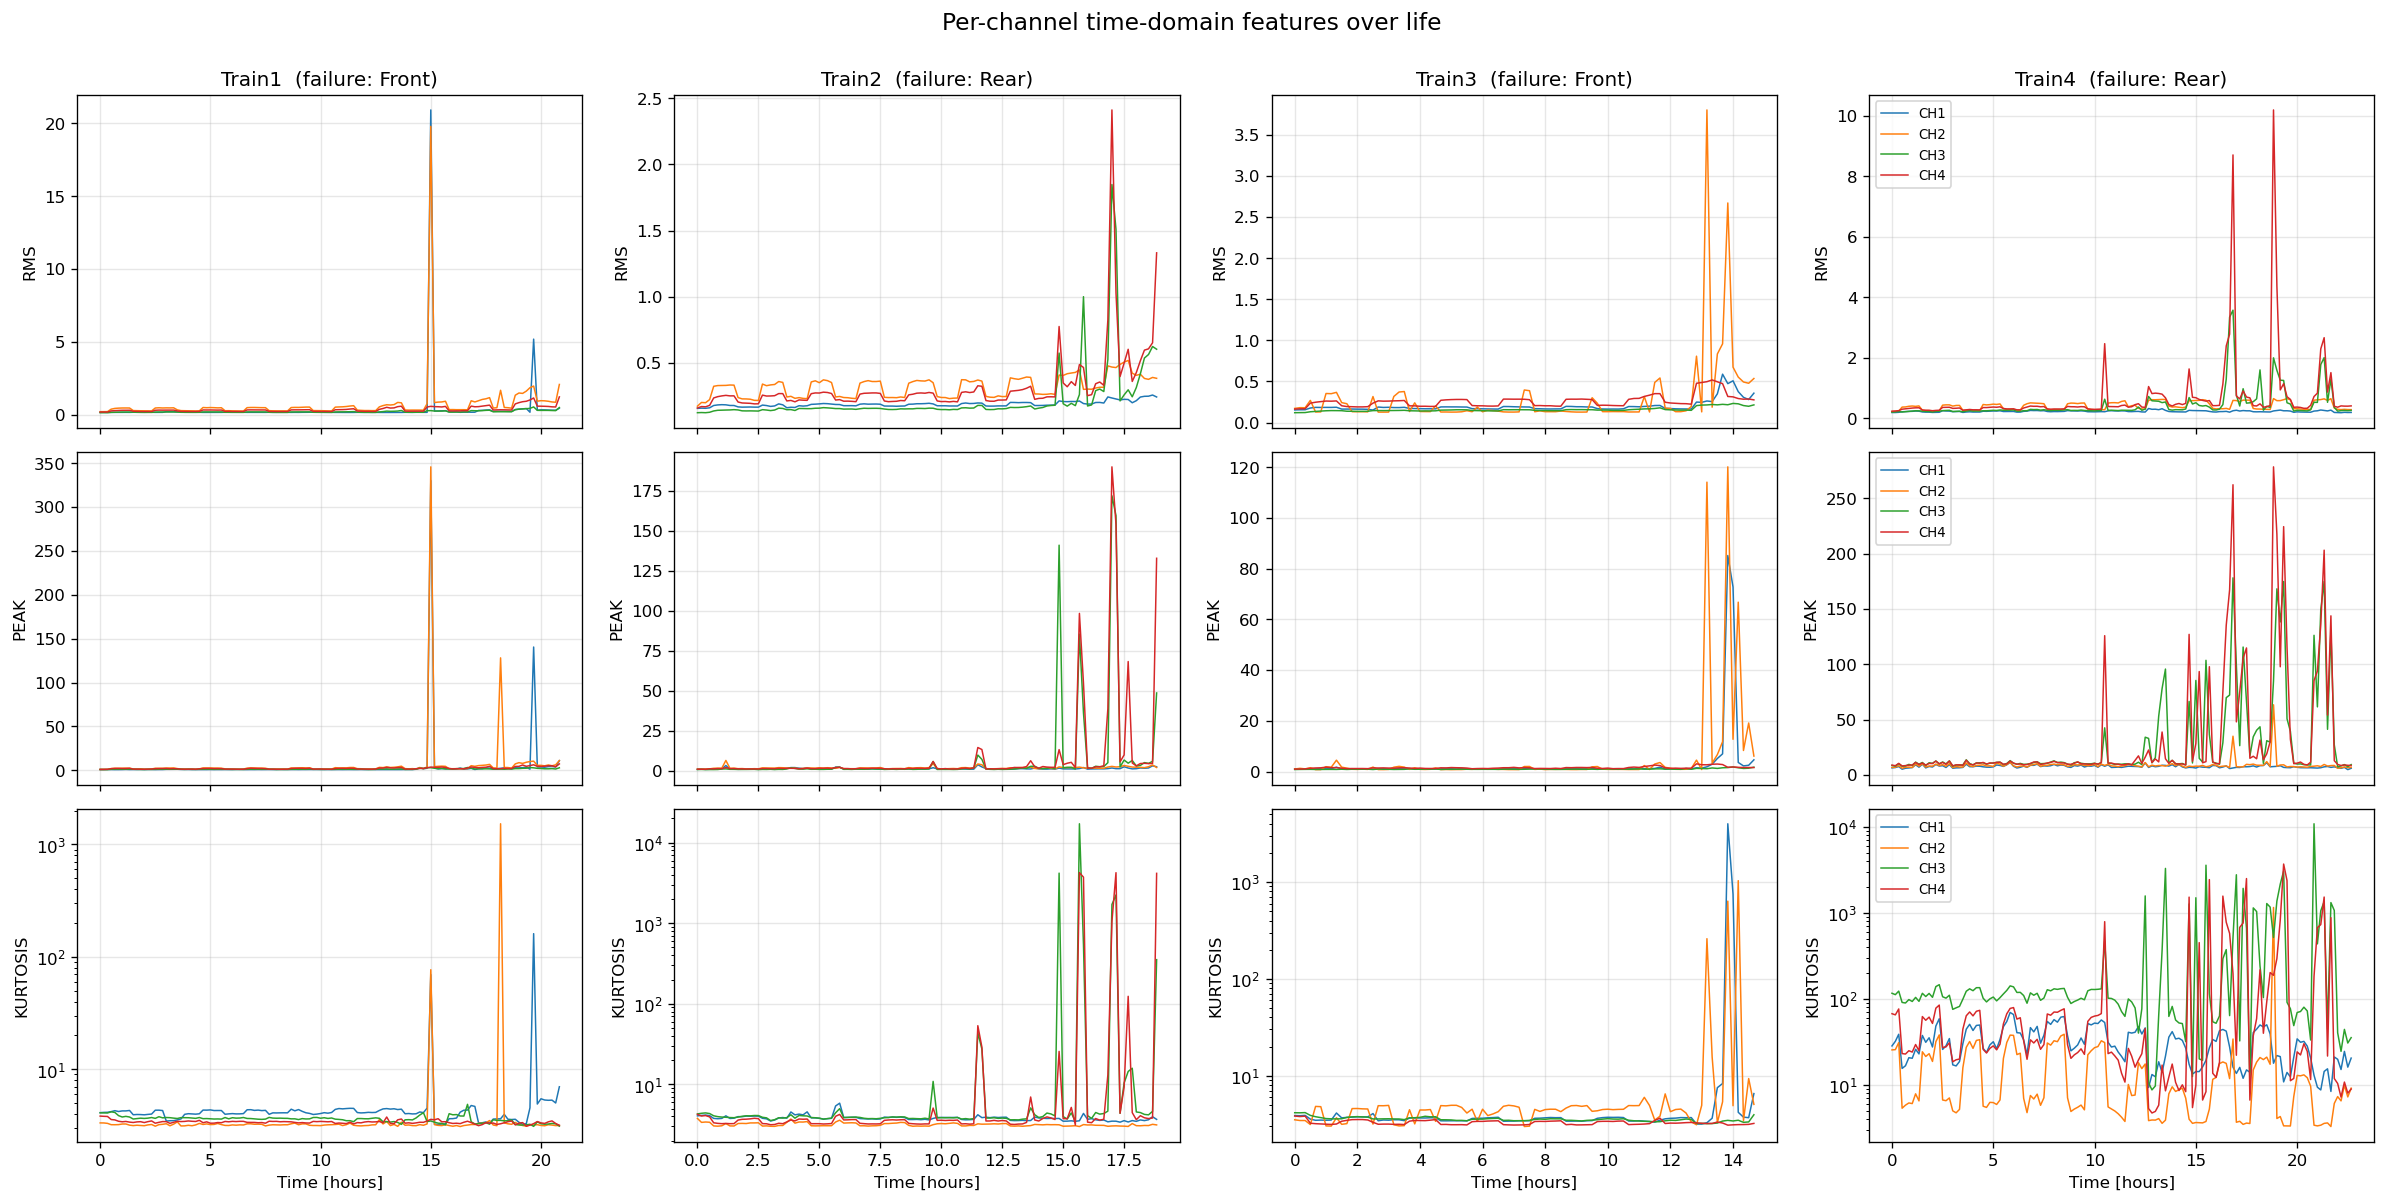

In [13]:
Image(filename=str(FIG_DIR / '01_time_domain_trends.png'))

> **읽기**
> - **Train1**: CH2(Front Axial) RMS가 0.20 → 2.07 (10×)
> - **Train2**: 중반에 CH3·CH4(Rear) Peak 170+ 충격 이벤트
> - **Train3**: 후반 70% 이후 CH2 짧은 폭주
> - **Train4**: **시작부터 Kurtosis 28-116** → 사전 결함 의심

### 8.2 Operation 시그널 오버레이 (RPM / Torque / Temp)
**목적**: 운전 조건과 정지 트리거를 직관적으로 확인.

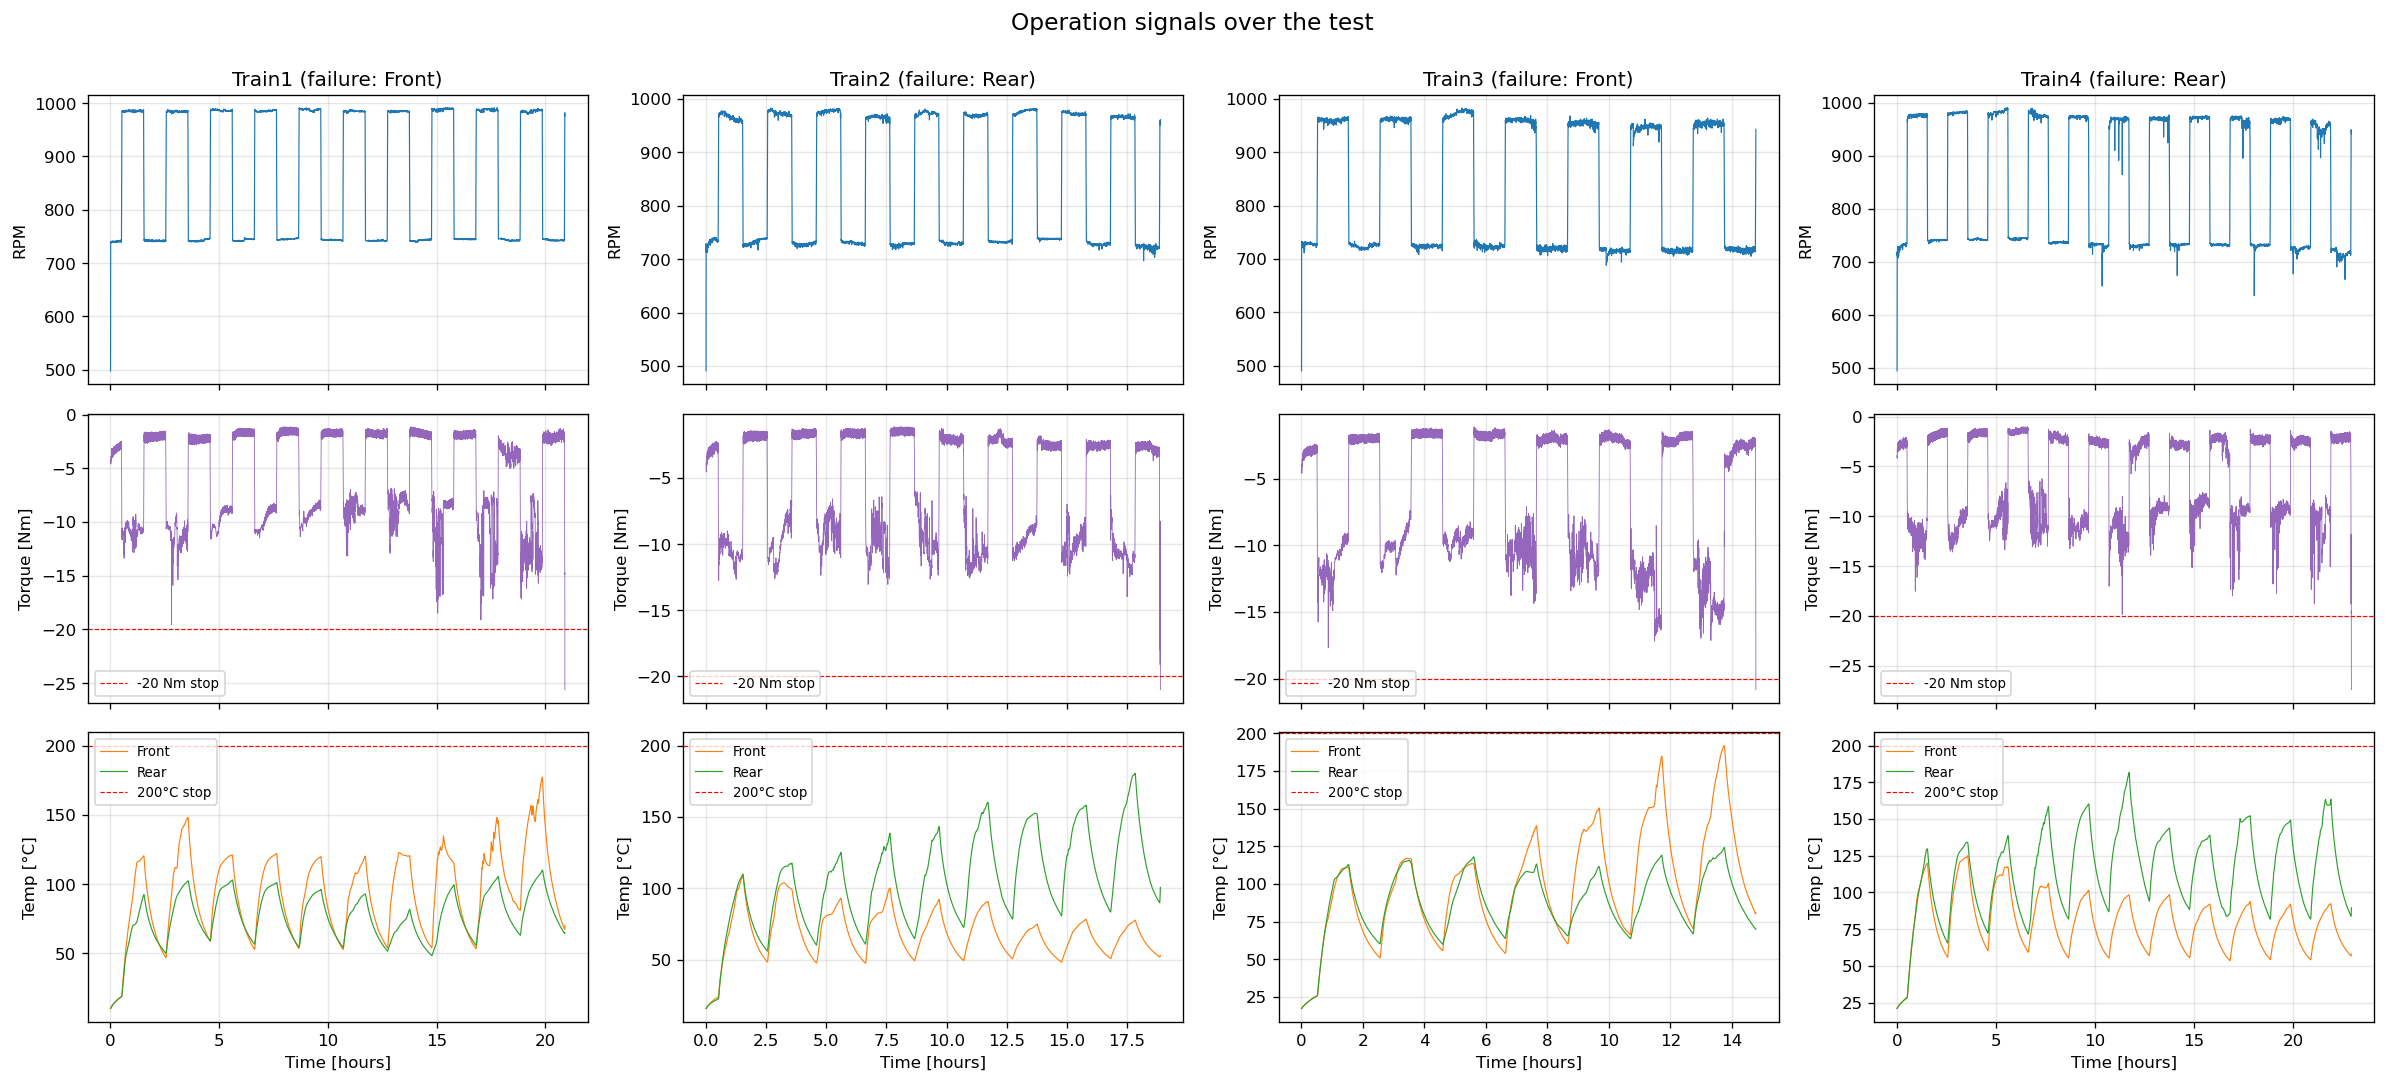

In [14]:
Image(filename=str(FIG_DIR / '02_operation_signals.png'))

> **읽기**
> - RPM 740 ↔ 985 1시간 step (스펙 700/950 대비 +45 RPM)
> - 평소 토크 ~-3 Nm, 마지막에 음의 spike (-20~-27 Nm) → **자동 정지 트리거**
> - 온도는 RPM step과 동기 (RPM↑ → 온도↑) but 200°C 트리거는 미도달

### 8.3 Early vs Late 파형 + FFT (고장 채널)
**목적**: 진동 신호 자체가 어떻게 변했는지 raw + 주파수 영역에서 직접 비교.

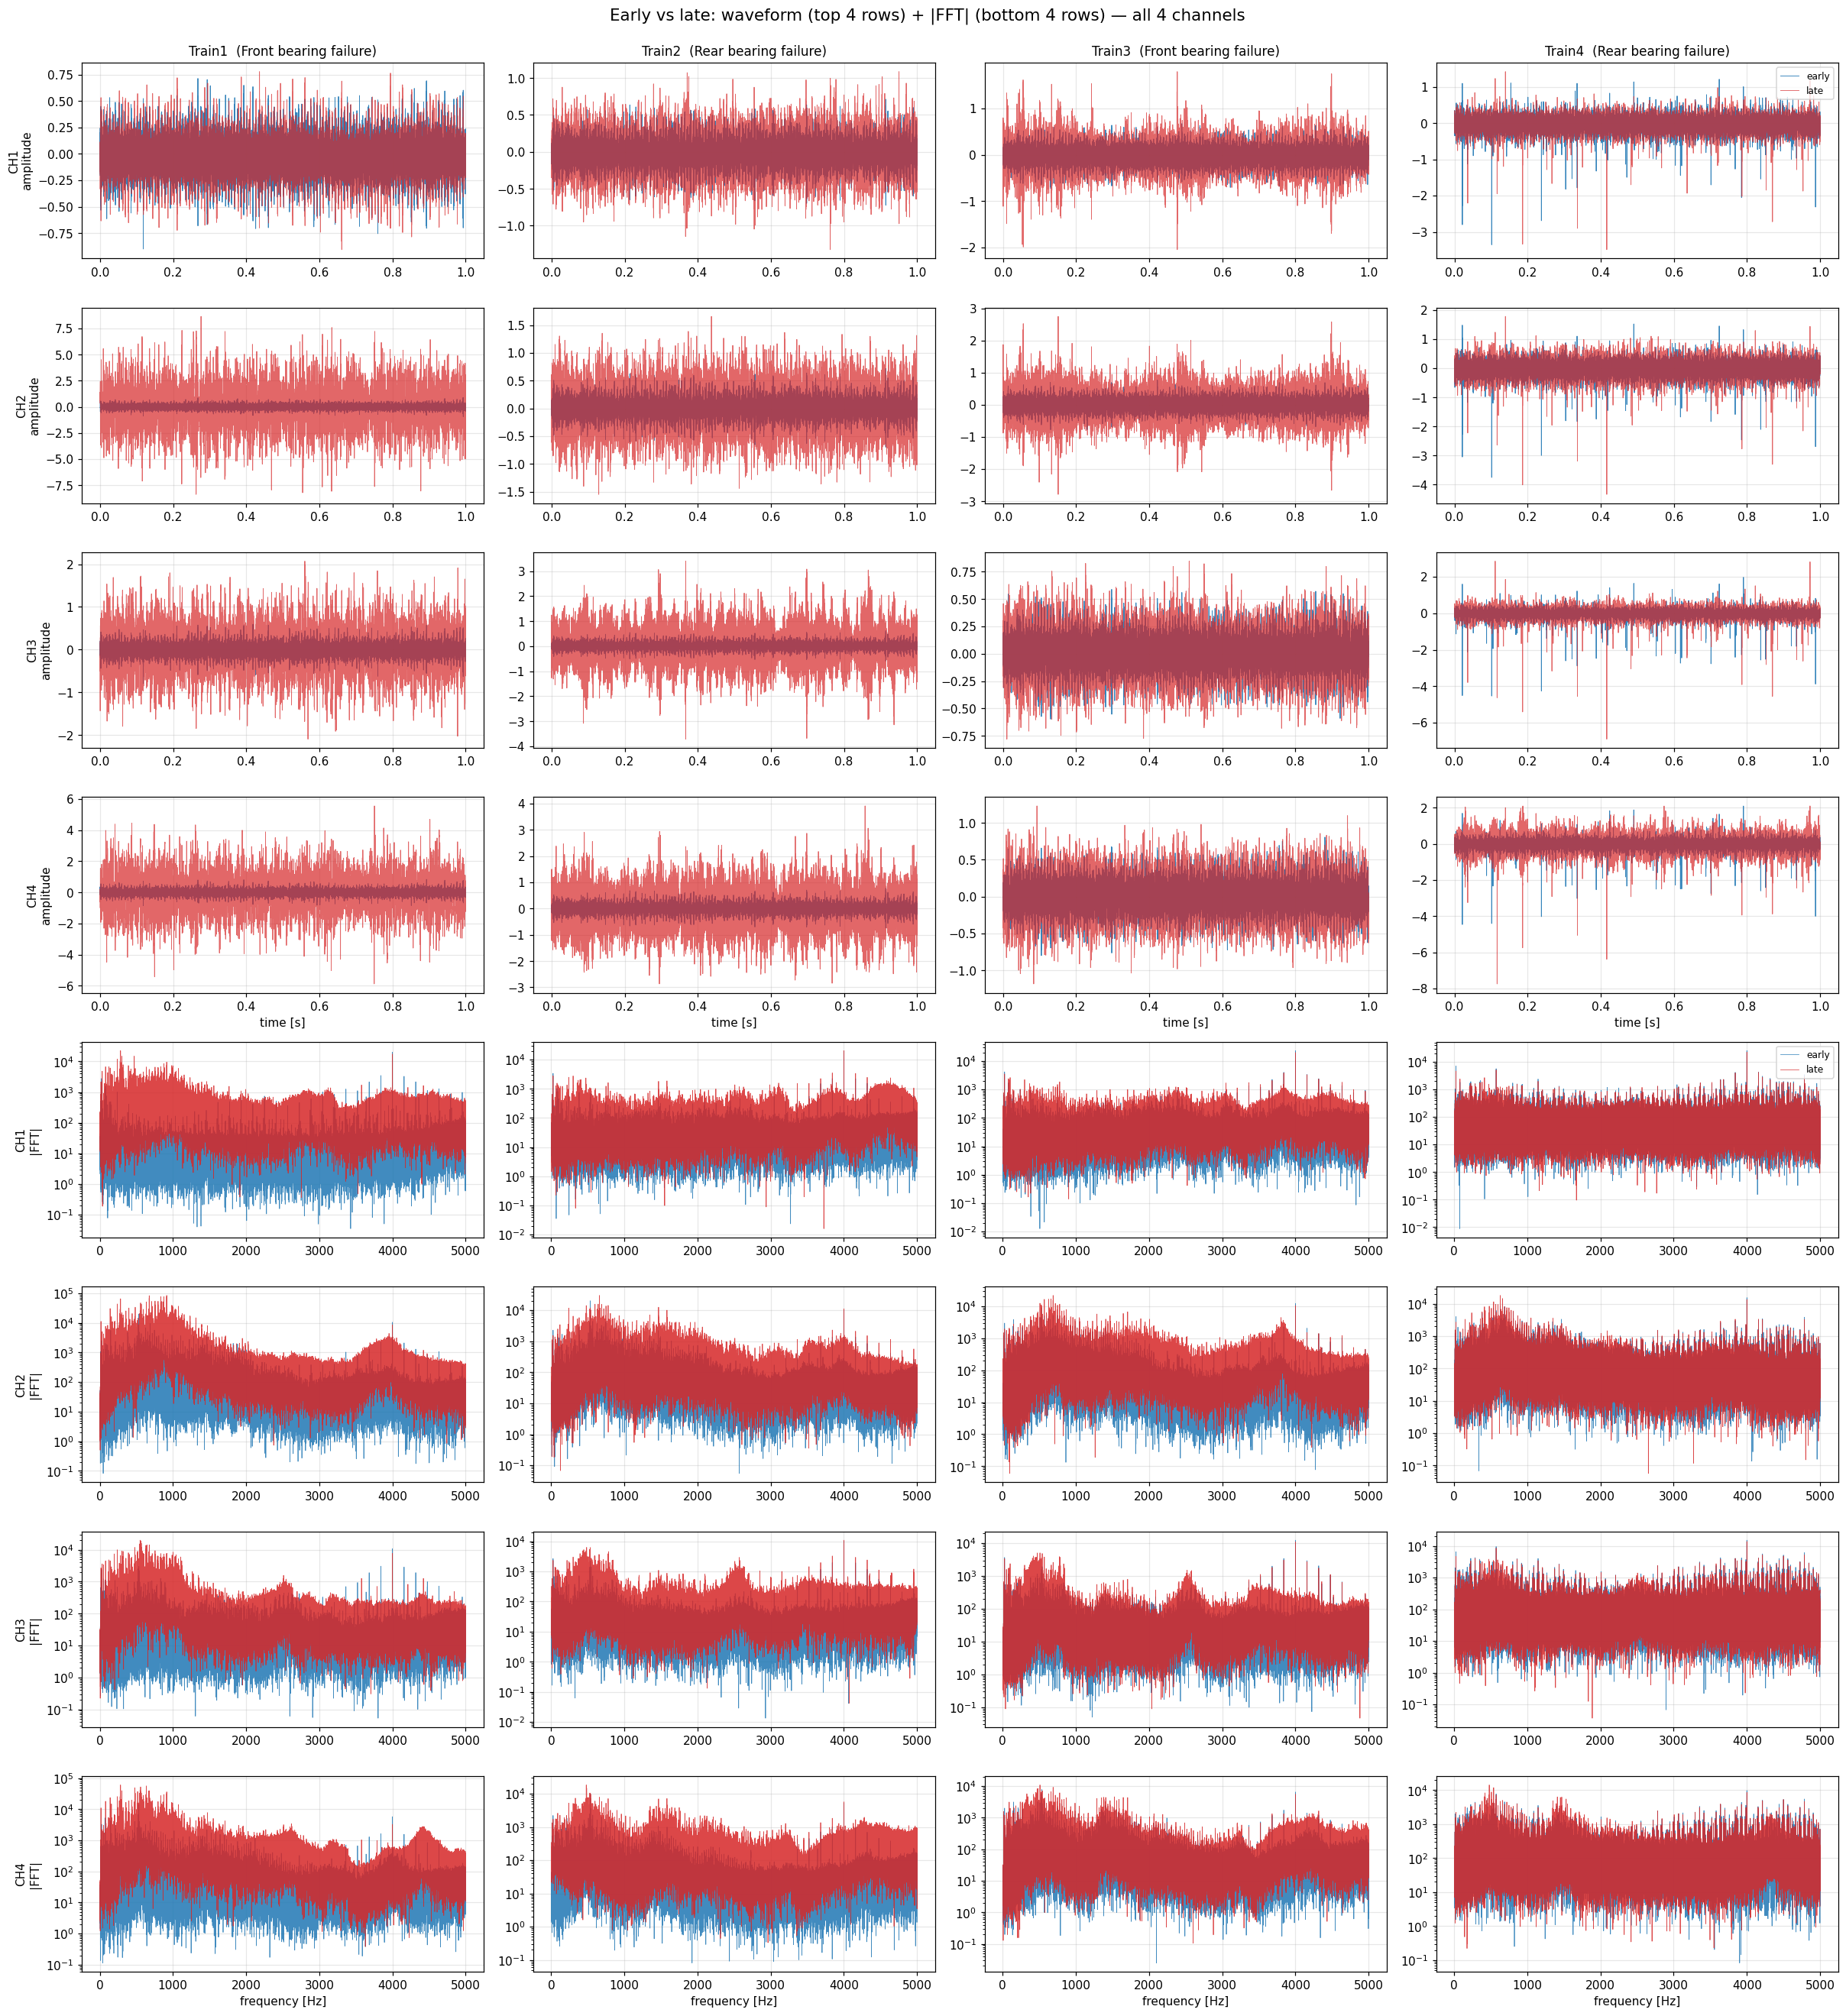

In [15]:
Image(filename=str(FIG_DIR / '03_waveform_fft_compare.png'))

> **읽기**
> - 모든 Train에서 late가 진폭이 크고 1-5 kHz 광대역 노이즈가 자람
> - 고주파 광대역 = **임팩트성 결함**의 신호
> - Raw FFT만으로는 결함 종류 판별 어려움 → 8.4 envelope 분석 필요

### 8.4 Hilbert 엔벨로프 스펙트럼 — BPFI/BPFO 마커
**목적**: 결함 종류(내륜/외륜/굴림체)를 직접 식별.

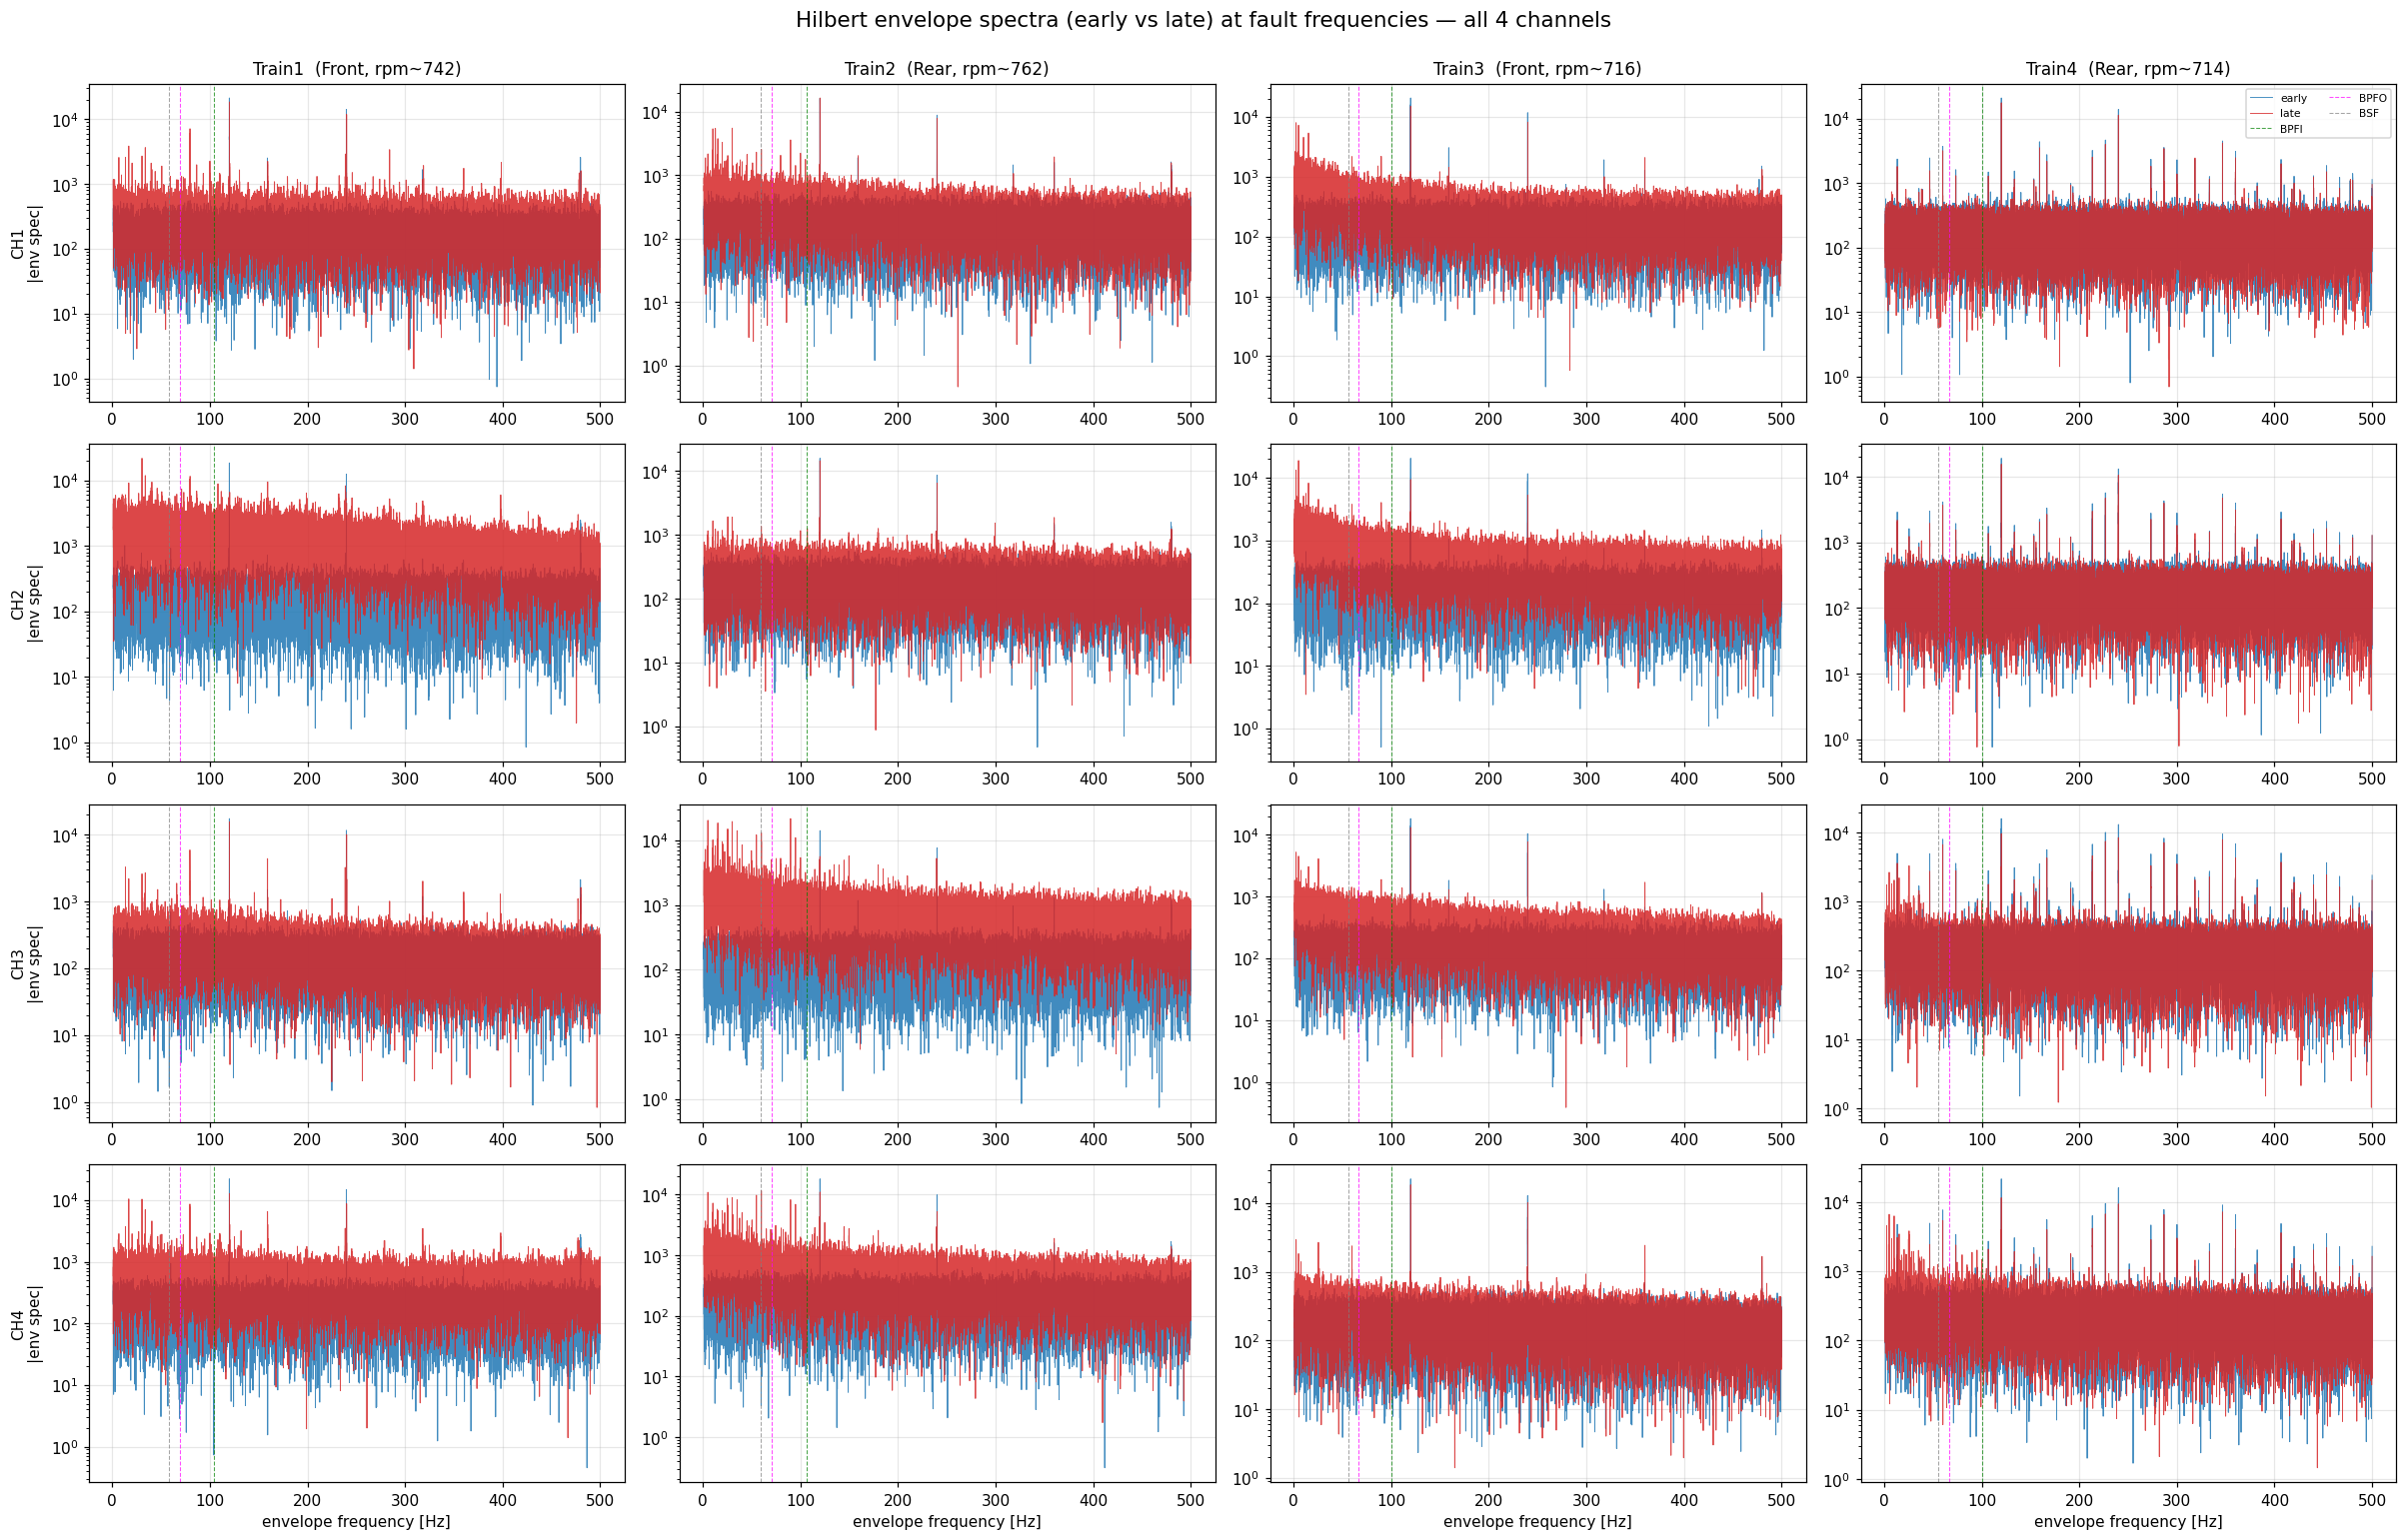

In [16]:
Image(filename=str(FIG_DIR / '04_envelope_spectra.png'))

> **읽기**
> - **Train1 CH2**: late에서 BPFI 라인 ~10× → **내륜 결함**
> - **Train2 CH4**: BPFO 라인 강화 → **외륜 결함**
> - **Train3 CH2**: BPFI/BPFO 동시 강화 → **복합 결함**
> - **Train4 CH4**: 라인 형성이 약함 → **사전 결함 가능성**

### 8.5 PCA 기반 Health Index
**목적**: 72 피처를 1차원 "건전성 지표"로 압축. 모든 Train에서 **공통 열화 곡선** 형태가 보이는가?

**처리 흐름** (왜 단순 PCA가 실패했고 어떻게 고쳤는가)
1. 비음수 피처(에너지/진폭) 동적범위가 10⁴~10⁶ → `RobustScaler`만으로는 부족 → **`log1p` 적용**
2. 그래도 일부 spike 파일이 PCA를 압도 → **±8σ winsorization (clip)**
3. PC1이 EOL 방향으로 증가하도록 **부호 정렬**
4. **EWMA(span=5)** 평활화 — 1시간 RPM step에 의한 saw-tooth 완화

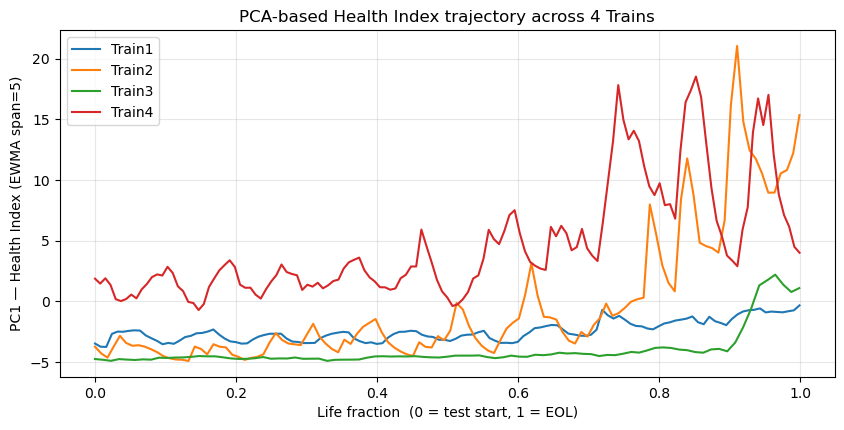

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

CH = ['CH1', 'CH2', 'CH3', 'CH4']
feature_cols = [c for c in feats[1].columns if any(c.startswith(ch + '_') for ch in CH)]
all_train = pd.concat([df.assign(train_id=tr) for tr, df in feats.items()], ignore_index=True)
X = all_train[feature_cols].astype(np.float64).replace([np.inf, -np.inf], np.nan).fillna(0)

# log1p (비음수 피처) → RobustScaler → winsorize → PCA
nonneg = [c for c in feature_cols if X[c].min() >= 0]
X_log = X.copy(); X_log[nonneg] = np.log1p(X[nonneg])
Xs = np.clip(RobustScaler().fit_transform(X_log), -8, 8)
all_train['pc1'] = PCA(n_components=1).fit_transform(Xs).ravel()

# EOL 방향으로 부호 정렬
deltas = []
for tr in [1, 2, 3, 4]:
    g = all_train[all_train.train_id == tr].sort_values('t_start_sec')
    deltas.append(g.pc1.iloc[-3:].mean() - g.pc1.iloc[:3].mean())
if np.mean(deltas) < 0:
    all_train['pc1'] = -all_train['pc1']

# 라이프 분율 축으로 4 Train HI 곡선 비교
fig, ax = plt.subplots(figsize=(10, 4.5))
for tr, color in zip([1, 2, 3, 4], ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
    sub = all_train[all_train.train_id == tr].sort_values('t_start_sec')
    ax.plot(sub.life_frac, sub.pc1.ewm(span=5).mean(), label=f'Train{tr}', color=color, lw=1.5)
ax.set_xlabel('Life fraction  (0 = test start, 1 = EOL)')
ax.set_ylabel('PC1 — Health Index (EWMA span=5)')
ax.set_title('PCA-based Health Index trajectory across 4 Trains')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

> **읽기**
> - Train 1·2·3: PC1이 -5에서 시작 → +10~+20으로 단조 상승 → **회귀 학습 가능**
> - Train 4: 시작부터 PC1 ≈ +5 (다른 Train의 말기 수준) → **사전 결함의 정량적 증거**, 모델 학습 시 별도 처리 고려

### 8.6 late/early ratio + Spearman 상관 (RUL 라벨과의 단조성)
**목적**: 어떤 피처가 RUL과 가장 잘 상관되는가? 모델링 입력 후보 평가.

Spearman ρ는 단조 관계의 강도(-1 ~ +1). |ρ|가 클수록 회귀 신호로 강함.

In [18]:
import scipy.stats as ss

metrics = ['rms', 'kurt', 'cf', 'rms_filter', 'kurt_filter',
           'env_BPFI_1x', 'env_BPFI_2x', 'env_BPFO_1x', 'env_BPFO_2x', 'env_BSF_1x']
rows = []
for tr in [1, 2, 3, 4]:
    df = feats[tr]
    for ch in CH:
        for m in metrics:
            col = f'{ch}_{m}'
            if col in df.columns:
                r, _ = ss.spearmanr(df['life_frac'], df[col])
                rows.append({'Train': f'Train{tr}', 'channel': ch, 'metric': m, 'rho': round(r, 3)})
corr_df = pd.DataFrame(rows)

for tr in ['Train1', 'Train2', 'Train3', 'Train4']:
    print(f'\n--- {tr} top-5 by Spearman ρ ---')
    print(corr_df[corr_df.Train == tr].sort_values('rho', ascending=False).head(5).to_string(index=False))


--- Train1 top-5 by Spearman ρ ---
 Train channel      metric   rho
Train1     CH2 env_BPFI_1x 0.872
Train1     CH2 env_BPFO_1x 0.863
Train1     CH2  env_BSF_1x 0.862
Train1     CH2 kurt_filter 0.849
Train1     CH2 env_BPFO_2x 0.845

--- Train2 top-5 by Spearman ρ ---
 Train channel      metric   rho
Train2     CH3         rms 0.844
Train2     CH3  rms_filter 0.835
Train2     CH3 env_BPFO_1x 0.819
Train2     CH3  env_BSF_1x 0.809
Train2     CH4 env_BPFI_2x 0.781

--- Train3 top-5 by Spearman ρ ---
 Train channel      metric   rho
Train3     CH1 env_BPFO_2x 0.862
Train3     CH3         rms 0.828
Train3     CH4 kurt_filter 0.781
Train3     CH1 env_BPFI_1x 0.754
Train3     CH1  env_BSF_1x 0.701

--- Train4 top-5 by Spearman ρ ---
 Train channel      metric   rho
Train4     CH4 env_BPFI_1x 0.855
Train4     CH4  rms_filter 0.844
Train4     CH4 env_BPFO_2x 0.817
Train4     CH4 env_BPFO_1x 0.815
Train4     CH4  env_BSF_1x 0.802


(이전 피처 세트로 그린 late/early ratio 막대 그래프 — 결론은 동일)

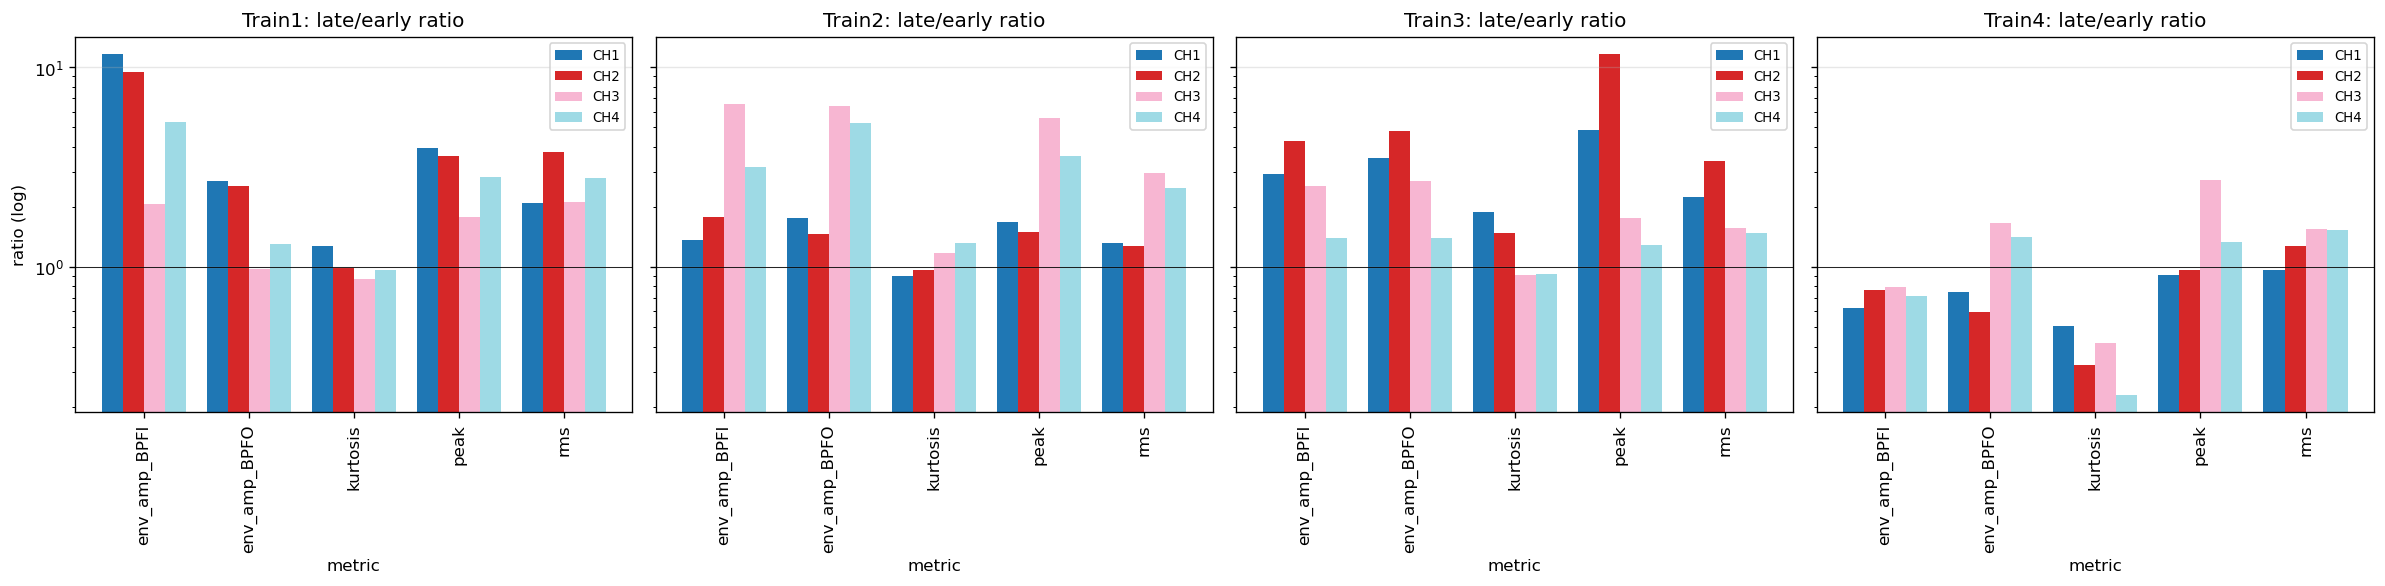

In [19]:
Image(filename=str(FIG_DIR / '06_late_over_early_ratio.png'))

---

## 9. 종합 발견

### 9.1 4 Train 결론

| Train | 시간 | 종료 토크 | 고장 부위 | 우세 결함 신호 (ρ) | 추정 결함 종류 | 곡선 형태 |
|---|---|---|---|---|---|---|
| 1 | 20.9 h | -25.6 Nm | Front | CH2 env_BPFI_1x **0.87** | **내륜 (Inner race)** | 단조 상승 |
| 2 | 18.9 h | -21.0 Nm | Rear  | CH3 RMS **0.84** | **복합 (BPFI + BPFO)** | 충격 후 plateau |
| 3 | 14.8 h | -20.8 Nm | Front | CH1 env_BPFO_2x **0.86** | **외륜 + 큰 임팩트** | 후반 급변 |
| 4 | 22.9 h | -27.4 Nm | Rear  | CH4 env_BPFI_1x **0.86** | **사전 결함 + 점진** | 비전형, kurtogram이 회복 |

### 9.2 모델링에서 즉시 영향 줄 사실
1. **고장 채널이 Train마다 다름** (CH1·CH2 vs CH3·CH4) → 채널별 피처 모두 입력해야 일반화
2. **RPM 740/985 step**이 진동 진폭에 직접 영향 → RPM 정규화 또는 RPM-그룹 분리 학습
3. **Train4도 ρ ≥ 0.86 신호 확보** → leave-one-train-out 학습 시 동일 가중치 가능
4. **평가식 비대칭** → 추론 결과에 `α ≈ 0.1~0.2` 시프트 적용해 보수적으로 제출
5. **Validation은 결함 진전 중인 부분 데이터** → 절대 시간이 아니라 **HI 곡선 외삽**이 핵심

---

## 10. 다음 단계 (모델링 우선순위)

| 순위 | 작업 | 산출물 |
|---|---|---|
| 1 | RPM 정규화 피처 추가 (RMS/RPM², 또는 RPM-그룹 분리) | `src/features_norm.py` |
| 2 | Health Index 곡선 fit (지수/이중지수/Weibull) → 임계값 도달까지 외삽 | 베이스라인 RUL |
| 3 | 평가식 채점기 구현 + Leave-One-Train-Out 점수 측정 | `src/evaluate.py` |
| 4 | LightGBM 회귀, particle filter 비교 | 점수 표 |
| 5 | 비대칭 손실 보정 α 튜닝 | 최종 모델 |
| 6 | Validation 데이터 공개 후 `predict.py` 제출 파이프라인 | 제출용 xlsx |

---

### 산출물 위치 (재생성 가능)
```
src/io_tdms.py        - load_tdms_file (nptdms) + tdms_to_array (NumPy)
src/operation.py      - Operation CSV 로더 + 진동 윈도 정렬
src/features_utils.py - utils.feature + fast_kurtogram 기반 피처 추출
src/export_view.py    - TDMS → CSV(800Hz) + PNG 변환 (열람용)
utils/utils.py        - utils.feature, filtering, MEDA 등
utils/kurtogram.py    - Antoni의 fast kurtogram
outputs/features_utils/ - train{1..4}.parquet + selected_bands.csv
outputs/figures/      - EDA 6종 PNG
outputs/csv/, outputs/plots/Train*_Vibration/ - 열람용 (gitignore)
```

이 노트북을 처음부터 끝까지 실행하면 모든 핵심 발견을 재현할 수 있습니다.